## Aligning Udemy dataset with Shaguf structure

To ensure a more meaningful integration, the Udemy dataset was transformed to match the structure of the Shaguf dataset.

This was done using feature engineering techniques, where new features were created or renamed to align with the cleaned Shaguf dataset.

The goal was to preserve as much useful information as possible while maintaining consistency between both datasets.

In [1]:
import pandas as pd
shaguf_df = pd.read_csv("shaguf_cleaned_final (1).csv")

shaguf_model = shaguf_df[[
    "students_capped",
    "price_clean",
    "is_free",
    "discount_rate_actual"
]].copy()

shaguf_model["source"] = "Shaguf"

shaguf_model.head()

,students_capped,price_clean,is_free,discount_rate_actual,source
0,1103,2520.0,False,0.00,Shaguf
1,101,31.0,False,62.65,Shaguf
2,111,42.0,False,57.86,Shaguf
3,0,10.0,False,87.95,Shaguf
4,113,43.0,False,56.86,Shaguf


In [2]:
udemy_df = pd.read_csv("udemy_courses_dataset.csv")

udemy_model = udemy_df[[
    "num_subscribers",
    "price",
    "content_duration",
    "is_paid",
    "level",
    "subject"
]].copy()

udemy_model = udemy_model.rename(columns={
    "num_subscribers": "students_capped",
    "price": "price_clean",
    "content_duration": "duration_clean"
})

udemy_model["is_free"] = ~udemy_model["is_paid"]
udemy_model = udemy_model.drop(columns=["is_paid"])

udemy_model["discount_rate_actual"] = 0
udemy_model["source"] = "Udemy"

udemy_model["students_capped"] = pd.to_numeric(udemy_model["students_capped"], errors="coerce")
udemy_model["price_clean"] = pd.to_numeric(udemy_model["price_clean"], errors="coerce")
udemy_model["duration_clean"] = pd.to_numeric(udemy_model["duration_clean"], errors="coerce")

udemy_model.head()

,students_capped,price_clean,duration_clean,level,subject,is_free,discount_rate_actual,source
0,2147,200,1.5,All Levels,Business Finance,False,0,Udemy
1,2792,75,39.0,All Levels,Business Finance,False,0,Udemy
2,2174,45,2.5,Intermediate Level,Business Finance,False,0,Udemy
3,2451,95,3.0,All Levels,Business Finance,False,0,Udemy
4,1276,200,2.0,Intermediate Level,Business Finance,False,0,Udemy


In [3]:
common_cols = [
    "students_capped",
    "price_clean",
    "is_free",
    "discount_rate_actual",
    "source"
]

shaguf_final = shaguf_model[common_cols]
udemy_final = udemy_model[common_cols]

In [4]:
combined_df = pd.concat([shaguf_final, udemy_final], ignore_index=True)

combined_df = combined_df.dropna()

combined_df.head()

,students_capped,price_clean,is_free,discount_rate_actual,source
0,1103,2520.0,False,0.00,Shaguf
1,101,31.0,False,62.65,Shaguf
2,111,42.0,False,57.86,Shaguf
3,0,10.0,False,87.95,Shaguf
4,113,43.0,False,56.86,Shaguf


In [5]:
print(combined_df.shape)
print(combined_df["source"].value_counts())
print(combined_df.isnull().sum())

(4638, 5)
source
Udemy     3678
Shaguf     960
Name: count, dtype: int64
students_capped         0
price_clean             0
is_free                 0
discount_rate_actual    0
source                  0
dtype: int64


In [6]:
import numpy as np

df_final = combined_df.copy()

# log transformations
df_final["students_log"] = np.log1p(df_final["students_capped"])
df_final["price_log"] = np.log1p(df_final["price_clean"])

# discount binary
df_final["has_discount"] = df_final["discount_rate_actual"] > 0

# optional: remove zeros
df_final = df_final[df_final["students_capped"] > 0]

df_final.head()

,students_capped,price_clean,is_free,discount_rate_actual,source,students_log,price_log,has_discount
0,1103,2520.0,False,0.00,Shaguf,7.006695,7.832411,False
1,101,31.0,False,62.65,Shaguf,4.624973,3.465736,True
2,111,42.0,False,57.86,Shaguf,4.718499,3.761200,True
4,113,43.0,False,56.86,Shaguf,4.736198,3.784190,True
6,2,1360.0,False,0.00,Shaguf,1.098612,7.215975,False


In [7]:
print(df_final.shape)
print(df_final.isnull().sum())
df_final.describe()

(3956, 8)
students_capped         0
price_clean             0
is_free                 0
discount_rate_actual    0
source                  0
students_log            0
price_log               0
has_discount            0
dtype: int64


,students_capped,price_clean,discount_rate_actual,students_log,price_log
count,3956.000000,3956.000000,3956.000000,3956.000000,3956.000000
mean,2992.729272,68.662791,7.129247,6.143632,3.569729
std,9194.602696,129.241872,24.045696,2.316020,1.364399
min,1.000000,0.000000,0.000000,0.693147,0.000000
25%,104.750000,20.000000,0.000000,4.661069,3.044522
50%,770.000000,40.000000,0.000000,6.647688,3.713572
75%,2310.250000,95.000000,0.000000,7.745544,4.564348
max,268923.000000,2994.000000,100.000000,12.502184,8.004700


In [8]:
df_final.to_csv("combined_courses_final_dataset.csv", index=False)
print("Final cleaned dataset saved successfully.")

Final cleaned dataset saved successfully.


# Baseline Model

In this step, we build a simple baseline model to predict student enrollment.

We use the final integrated dataset prepared after cleaning and feature improvement.

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## Load the final dataset

We load the final cleaned dataset that combines Shaguf and Udemy.

In [10]:
df_final = pd.read_csv("combined_courses_final_dataset.csv")
df_final.head()

,students_capped,price_clean,is_free,discount_rate_actual,source,students_log,price_log,has_discount
0,1103,2520.0,False,0.00,Shaguf,7.006695,7.832411,False
1,101,31.0,False,62.65,Shaguf,4.624973,3.465736,True
2,111,42.0,False,57.86,Shaguf,4.718499,3.761200,True
3,113,43.0,False,56.86,Shaguf,4.736198,3.784190,True
4,2,1360.0,False,0.00,Shaguf,1.098612,7.215975,False


## Select features and target

We use a small set of simple features for the baseline model.

The target is the log-transformed number of students.

In [11]:
X = df_final[["price_log", "is_free", "has_discount"]]
y = df_final["students_log"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (3956, 3)
y shape: (3956,)


## Split the data

We divide the data into training and testing sets to evaluate the model fairly.

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (3164, 3)
Testing set: (792, 3)


## Build the baseline model

We use Linear Regression because it is simple and suitable for a baseline regression task.

In [13]:
baseline_model = LinearRegression()
baseline_model.fit(X_train, y_train)

LinearRegression()

## Make predictions

Now we use the model to predict student enrollment on the testing set.

In [14]:
y_pred = baseline_model.predict(X_test)
y_pred[:10]

array([3.7790234 , 5.94762764, 5.54195544, 5.54195544, 2.69260622,
       5.94762764, 6.46348807, 6.52357094, 5.77810388, 6.49427341])

## Evaluate the model

We evaluate the baseline model using MAE, RMSE, and R².

In [15]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Baseline Model: Linear Regression")
print("MAE =", mae)
print("RMSE =", rmse)
print("R² =", r2)

Baseline Model: Linear Regression
MAE = 1.6617210811387653
RMSE = 2.048778531994281
R² = 0.1612593991585458


## Visual check of model performance

To better understand the baseline model, we add simple visualizations showing prediction quality and error behavior.

## Actual vs Predicted values

This plot compares the actual target values with the predicted values.

If the model performs well, the points should appear reasonably close instead of being widely scattered.

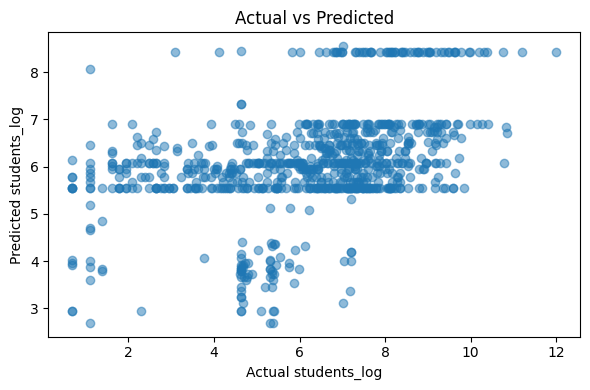

In [16]:
plt.figure(figsize=(6,4))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Actual students_log")
plt.ylabel("Predicted students_log")
plt.title("Actual vs Predicted")
plt.tight_layout()
plt.show()

## Residual plot

This plot shows the residuals, which are the differences between actual and predicted values.

It helps us see whether the prediction errors are randomly distributed or if there is a visible pattern.

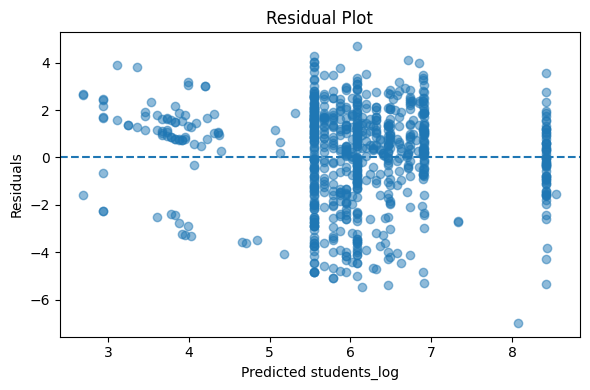

In [17]:
residuals = y_test - y_pred

plt.figure(figsize=(6,4))
plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted students_log")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.tight_layout()
plt.show()

## Short note on the plots

These plots do not replace the evaluation metrics, but they give a quick visual understanding of how the baseline model performs and how the prediction errors are distributed.


## Short interpretation

This baseline model gives us a simple starting point.

Its goal is not to be the best model, but to provide a basic benchmark for comparison with later models.

## Why log transformation was used

We used log transformation for students and price because the original values were highly skewed.

This helps make the data more stable for modelling.

In [18]:
results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

results.head(10)

,Actual,Predicted
0,4.634729,3.779023
1,1.791759,5.947628
2,8.537976,5.541955
3,8.132706,5.541955
4,5.370638,2.692606
5,1.098612,5.947628
6,5.869297,6.463488
7,9.002332,6.523571
8,6.388561,5.778104
9,5.327876,6.494273


## Final note

This baseline model will be used as the reference point in Phase 3 before testing more advanced models.